<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/03_fundamental_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 3: Fundamental Analysis

This notebook fetches key financial ratios and fundamentals for all NIFTY 50 stocks
using yfinance and scores each stock based on its financial health.

**Metrics covered:** P/E, P/B, ROE, EPS, Debt/Equity, Revenue Growth, Profit Margins
**Output:** Fundamental scores + Power BI ready CSV


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install yfinance pyarrow -q

import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

BASE = '/content/drive/MyDrive/indian_stock_analysis'

print("✅ Ready!")

Mounted at /content/drive
✅ Ready!


In [2]:
NIFTY_50 = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ICICIBANK.NS",
    "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "BHARTIARTL.NS", "KOTAKBANK.NS",
    "LT.NS", "AXISBANK.NS", "ASIANPAINT.NS", "MARUTI.NS", "SUNPHARMA.NS",
    "TITAN.NS", "ULTRACEMCO.NS", "BAJFINANCE.NS", "WIPRO.NS", "ONGC.NS",
    "NTPC.NS", "POWERGRID.NS", "TECHM.NS", "HCLTECH.NS", "JSWSTEEL.NS",
    "TATASTEEL.NS", "TATAMOTORS.NS", "NESTLEIND.NS", "DRREDDY.NS", "DIVISLAB.NS",
    "CIPLA.NS", "COALINDIA.NS", "BPCL.NS", "GRASIM.NS", "ADANIENT.NS",
    "ADANIPORTS.NS", "BAJAJFINSV.NS", "BAJAJ-AUTO.NS", "HEROMOTOCO.NS", "EICHERMOT.NS",
    "BRITANNIA.NS", "HINDALCO.NS", "UPL.NS", "SBILIFE.NS", "HDFCLIFE.NS",
    "APOLLOHOSP.NS", "TATACONSUM.NS", "INDUSINDBK.NS", "M&M.NS", "LTF.NS"
]

SECTOR_MAP = {
    "RELIANCE.NS": "Energy", "TCS.NS": "IT", "HDFCBANK.NS": "Banking",
    "INFY.NS": "IT", "ICICIBANK.NS": "Banking", "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG", "SBIN.NS": "Banking", "BHARTIARTL.NS": "Telecom",
    "KOTAKBANK.NS": "Banking", "LT.NS": "Infrastructure", "AXISBANK.NS": "Banking",
    "ASIANPAINT.NS": "Paints", "MARUTI.NS": "Auto", "SUNPHARMA.NS": "Pharma",
    "TITAN.NS": "Consumer", "ULTRACEMCO.NS": "Cement", "BAJFINANCE.NS": "NBFC",
    "WIPRO.NS": "IT", "ONGC.NS": "Energy", "NTPC.NS": "Power",
    "POWERGRID.NS": "Power", "TECHM.NS": "IT", "HCLTECH.NS": "IT",
    "JSWSTEEL.NS": "Steel", "TATASTEEL.NS": "Steel", "TATAMOTORS.NS": "Auto",
    "NESTLEIND.NS": "FMCG", "DRREDDY.NS": "Pharma", "DIVISLAB.NS": "Pharma",
    "CIPLA.NS": "Pharma", "COALINDIA.NS": "Mining", "BPCL.NS": "Energy",
    "GRASIM.NS": "Cement", "ADANIENT.NS": "Conglomerate", "ADANIPORTS.NS": "Ports",
    "BAJAJFINSV.NS": "NBFC", "BAJAJ-AUTO.NS": "Auto", "HEROMOTOCO.NS": "Auto",
    "EICHERMOT.NS": "Auto", "BRITANNIA.NS": "FMCG", "HINDALCO.NS": "Metals",
    "UPL.NS": "Agrochemicals", "SBILIFE.NS": "Insurance", "HDFCLIFE.NS": "Insurance",
    "APOLLOHOSP.NS": "Healthcare", "TATACONSUM.NS": "FMCG",
    "INDUSINDBK.NS": "Banking", "M&M.NS": "Auto", "LTF.NS": "NBFC"
}

print(f"✅ {len(NIFTY_50)} stocks defined across {len(set(SECTOR_MAP.values()))} sectors")

✅ 50 stocks defined across 21 sectors


In [3]:
def fetch_fundamentals(ticker):
    """Fetch all fundamental data for a single stock"""
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info

        data = {
            # Identity
            "Ticker":               ticker,
            "Company":              info.get("longName",            "N/A"),
            "Sector":               SECTOR_MAP.get(ticker,          "Unknown"),
            "Industry":             info.get("industry",            "N/A"),
            "Market_Cap_Cr":        round(info.get("marketCap", 0) / 1e7, 2),

            # Valuation Ratios
            "PE_Ratio":             info.get("trailingPE",          None),
            "Forward_PE":           info.get("forwardPE",           None),
            "PB_Ratio":             info.get("priceToBook",         None),
            "PS_Ratio":             info.get("priceToSalesTrailing12Months", None),
            "EV_EBITDA":            info.get("enterpriseToEbitda",  None),

            # Profitability
            "ROE_Pct":              round(info.get("returnOnEquity",  0) * 100, 2) if info.get("returnOnEquity")  else None,
            "ROA_Pct":              round(info.get("returnOnAssets",  0) * 100, 2) if info.get("returnOnAssets")  else None,
            "Profit_Margin_Pct":    round(info.get("profitMargins",   0) * 100, 2) if info.get("profitMargins")   else None,
            "Operating_Margin_Pct": round(info.get("operatingMargins",0) * 100, 2) if info.get("operatingMargins") else None,

            # Growth
            "Revenue_Growth_Pct":   round(info.get("revenueGrowth",  0) * 100, 2) if info.get("revenueGrowth")   else None,
            "Earnings_Growth_Pct":  round(info.get("earningsGrowth", 0) * 100, 2) if info.get("earningsGrowth")  else None,

            # Financial Health
            "Debt_To_Equity":       info.get("debtToEquity",        None),
            "Current_Ratio":        info.get("currentRatio",        None),
            "Quick_Ratio":          info.get("quickRatio",          None),

            # Per Share
            "EPS":                  info.get("trailingEps",         None),
            "Book_Value":           info.get("bookValue",           None),
            "Dividend_Yield_Pct":   round(info.get("dividendYield", 0) * 100, 2) if info.get("dividendYield") else 0,

            # Price
            "Current_Price":        info.get("currentPrice",        info.get("regularMarketPrice", None)),
            "52W_High":             info.get("fiftyTwoWeekHigh",    None),
            "52W_Low":              info.get("fiftyTwoWeekLow",     None),
        }

        return data

    except Exception as e:
        print(f"  ❌ Error fetching {ticker}: {e}")
        return None


def fetch_all_fundamentals():
    """Fetch fundamentals for all NIFTY 50 stocks"""
    all_data = []

    print(f"📥 Fetching fundamentals for {len(NIFTY_50)} stocks...\n")

    for i, ticker in enumerate(NIFTY_50, 1):
        print(f"  [{i:02d}/{len(NIFTY_50)}] Fetching {ticker}...", end=" ")
        data = fetch_fundamentals(ticker)
        if data:
            all_data.append(data)
            print(f"✅ {data['Company']}")
        else:
            print("❌ Skipped")

    fund_df = pd.DataFrame(all_data)
    print(f"\n✅ Fetched {len(fund_df)} stocks successfully!")
    return fund_df

fund_df = fetch_all_fundamentals()

📥 Fetching fundamentals for 50 stocks...

  [01/50] Fetching RELIANCE.NS... ✅ Reliance Industries Limited
  [02/50] Fetching TCS.NS... ✅ Tata Consultancy Services Limited
  [03/50] Fetching HDFCBANK.NS... ✅ HDFC Bank Limited
  [04/50] Fetching INFY.NS... ✅ Infosys Limited
  [05/50] Fetching ICICIBANK.NS... ✅ ICICI Bank Limited
  [06/50] Fetching HINDUNILVR.NS... ✅ Hindustan Unilever Limited
  [07/50] Fetching ITC.NS... ✅ ITC Limited
  [08/50] Fetching SBIN.NS... ✅ State Bank of India
  [09/50] Fetching BHARTIARTL.NS... ✅ Bharti Airtel Limited
  [10/50] Fetching KOTAKBANK.NS... ✅ Kotak Mahindra Bank Limited
  [11/50] Fetching LT.NS... ✅ Larsen & Toubro Limited
  [12/50] Fetching AXISBANK.NS... ✅ Axis Bank Limited
  [13/50] Fetching ASIANPAINT.NS... ✅ Asian Paints Limited
  [14/50] Fetching MARUTI.NS... ✅ Maruti Suzuki India Limited
  [15/50] Fetching SUNPHARMA.NS... ✅ Sun Pharmaceutical Industries Limited
  [16/50] Fetching TITAN.NS... ✅ Titan Company Limited
  [17/50] Fetching ULTRACEM

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}


✅ JSW Steel Limited
  [26/50] Fetching TATASTEEL.NS... ✅ Tata Steel Limited
  [27/50] Fetching TATAMOTORS.NS... ✅ N/A
  [28/50] Fetching NESTLEIND.NS... ✅ Nestlé India Limited
  [29/50] Fetching DRREDDY.NS... ✅ Dr. Reddy's Laboratories Limited
  [30/50] Fetching DIVISLAB.NS... ✅ Divi's Laboratories Limited
  [31/50] Fetching CIPLA.NS... ✅ Cipla Limited
  [32/50] Fetching COALINDIA.NS... ✅ Coal India Limited
  [33/50] Fetching BPCL.NS... ✅ Bharat Petroleum Corporation Limited
  [34/50] Fetching GRASIM.NS... ✅ Grasim Industries Limited
  [35/50] Fetching ADANIENT.NS... ✅ Adani Enterprises Limited
  [36/50] Fetching ADANIPORTS.NS... ✅ Adani Ports and Special Economic Zone Limited
  [37/50] Fetching BAJAJFINSV.NS... ✅ Bajaj Finserv Ltd.
  [38/50] Fetching BAJAJ-AUTO.NS... ✅ Bajaj Auto Limited
  [39/50] Fetching HEROMOTOCO.NS... ✅ Hero MotoCorp Limited
  [40/50] Fetching EICHERMOT.NS... ✅ Eicher Motors Limited
  [41/50] Fetching BRITANNIA.NS... ✅ Britannia Industries Limited
  [42/50] Fetch

In [4]:
def score_fundamentals(df):
    """
    Score each stock from 0–100 based on fundamental health.
    Higher = financially stronger stock.
    """
    df = df.copy()
    df["Fund_Score"] = 0

    # ── Valuation (lower P/E & P/B = better value) ──
    df.loc[df["PE_Ratio"].between(0, 15),  "Fund_Score"] += 15
    df.loc[df["PE_Ratio"].between(15, 25), "Fund_Score"] += 10
    df.loc[df["PE_Ratio"].between(25, 40), "Fund_Score"] += 5

    df.loc[df["PB_Ratio"].between(0, 1),  "Fund_Score"] += 10
    df.loc[df["PB_Ratio"].between(1, 3),  "Fund_Score"] += 7
    df.loc[df["PB_Ratio"].between(3, 5),  "Fund_Score"] += 4

    # ── Profitability ──
    df.loc[df["ROE_Pct"] > 20,  "Fund_Score"] += 20
    df.loc[df["ROE_Pct"].between(15, 20), "Fund_Score"] += 15
    df.loc[df["ROE_Pct"].between(10, 15), "Fund_Score"] += 10

    df.loc[df["Profit_Margin_Pct"] > 20, "Fund_Score"] += 15
    df.loc[df["Profit_Margin_Pct"].between(10, 20), "Fund_Score"] += 10
    df.loc[df["Profit_Margin_Pct"].between(5, 10),  "Fund_Score"] += 5

    # ── Growth ──
    df.loc[df["Revenue_Growth_Pct"] > 20,  "Fund_Score"] += 15
    df.loc[df["Revenue_Growth_Pct"].between(10, 20), "Fund_Score"] += 10
    df.loc[df["Revenue_Growth_Pct"].between(5, 10),  "Fund_Score"] += 5

    # ── Financial Health ──
    df.loc[df["Debt_To_Equity"] < 0.5,             "Fund_Score"] += 15
    df.loc[df["Debt_To_Equity"].between(0.5, 1.0), "Fund_Score"] += 10
    df.loc[df["Debt_To_Equity"].between(1.0, 2.0), "Fund_Score"] += 5

    df.loc[df["Current_Ratio"] > 2,              "Fund_Score"] += 10
    df.loc[df["Current_Ratio"].between(1.5, 2),  "Fund_Score"] += 7
    df.loc[df["Current_Ratio"].between(1.0, 1.5),"Fund_Score"] += 4

    # ── Grade ──
    df["Fund_Grade"] = "F"
    df.loc[df["Fund_Score"] >= 70, "Fund_Grade"] = "A"
    df.loc[df["Fund_Score"].between(55, 69), "Fund_Grade"] = "B"
    df.loc[df["Fund_Score"].between(40, 54), "Fund_Grade"] = "C"
    df.loc[df["Fund_Score"].between(25, 39), "Fund_Grade"] = "D"

    print("✅ Fundamental scores calculated!\n")
    print("📊 Top 15 Fundamentally Strong Stocks:")
    top = df.sort_values("Fund_Score", ascending=False)[
        ["Ticker", "Company", "Sector", "PE_Ratio", "ROE_Pct",
         "Profit_Margin_Pct", "Debt_To_Equity", "Fund_Score", "Fund_Grade"]
    ].head(15)
    print(top.to_string(index=False))

    return df

fund_df = score_fundamentals(fund_df)

✅ Fundamental scores calculated!

📊 Top 15 Fundamentally Strong Stocks:
       Ticker                                       Company  Sector  PE_Ratio  ROE_Pct  Profit_Margin_Pct  Debt_To_Equity  Fund_Score Fund_Grade
 COALINDIA.NS                            Coal India Limited  Mining  8.750991    28.12              18.46          11.629          69          B
       LTF.NS                           L&T Finance Limited    NBFC 24.962120    11.12              33.08         393.442          67          B
HEROMOTOCO.NS                         Hero MotoCorp Limited    Auto 17.090807    28.03              12.11           3.570          66          B
  JSWSTEEL.NS                             JSW Steel Limited   Steel 13.485212    27.26              12.03          94.155          63          B
 ICICIBANK.NS                            ICICI Bank Limited Banking 18.361181    16.36              24.93             NaN          62          B
     WIPRO.NS                                 Wipro Limite

In [5]:
def score_fundamentals(df):
    """
    Score each stock from 0–100 based on fundamental health.
    Higher = financially stronger stock.
    """
    df = df.copy()
    df["Fund_Score"] = 0

    # ── Valuation (lower P/E & P/B = better value) ──
    df.loc[df["PE_Ratio"].between(0, 15),  "Fund_Score"] += 15
    df.loc[df["PE_Ratio"].between(15, 25), "Fund_Score"] += 10
    df.loc[df["PE_Ratio"].between(25, 40), "Fund_Score"] += 5

    df.loc[df["PB_Ratio"].between(0, 1),  "Fund_Score"] += 10
    df.loc[df["PB_Ratio"].between(1, 3),  "Fund_Score"] += 7
    df.loc[df["PB_Ratio"].between(3, 5),  "Fund_Score"] += 4

    # ── Profitability ──
    df.loc[df["ROE_Pct"] > 20,  "Fund_Score"] += 20
    df.loc[df["ROE_Pct"].between(15, 20), "Fund_Score"] += 15
    df.loc[df["ROE_Pct"].between(10, 15), "Fund_Score"] += 10

    df.loc[df["Profit_Margin_Pct"] > 20, "Fund_Score"] += 15
    df.loc[df["Profit_Margin_Pct"].between(10, 20), "Fund_Score"] += 10
    df.loc[df["Profit_Margin_Pct"].between(5, 10),  "Fund_Score"] += 5

    # ── Growth ──
    df.loc[df["Revenue_Growth_Pct"] > 20,  "Fund_Score"] += 15
    df.loc[df["Revenue_Growth_Pct"].between(10, 20), "Fund_Score"] += 10
    df.loc[df["Revenue_Growth_Pct"].between(5, 10),  "Fund_Score"] += 5

    # ── Financial Health ──
    df.loc[df["Debt_To_Equity"] < 0.5,             "Fund_Score"] += 15
    df.loc[df["Debt_To_Equity"].between(0.5, 1.0), "Fund_Score"] += 10
    df.loc[df["Debt_To_Equity"].between(1.0, 2.0), "Fund_Score"] += 5

    df.loc[df["Current_Ratio"] > 2,              "Fund_Score"] += 10
    df.loc[df["Current_Ratio"].between(1.5, 2),  "Fund_Score"] += 7
    df.loc[df["Current_Ratio"].between(1.0, 1.5),"Fund_Score"] += 4

    # ── Grade ──
    df["Fund_Grade"] = "F"
    df.loc[df["Fund_Score"] >= 70, "Fund_Grade"] = "A"
    df.loc[df["Fund_Score"].between(55, 69), "Fund_Grade"] = "B"
    df.loc[df["Fund_Score"].between(40, 54), "Fund_Grade"] = "C"
    df.loc[df["Fund_Score"].between(25, 39), "Fund_Grade"] = "D"

    print("✅ Fundamental scores calculated!\n")
    print("📊 Top 15 Fundamentally Strong Stocks:")
    top = df.sort_values("Fund_Score", ascending=False)[
        ["Ticker", "Company", "Sector", "PE_Ratio", "ROE_Pct",
         "Profit_Margin_Pct", "Debt_To_Equity", "Fund_Score", "Fund_Grade"]
    ].head(15)
    print(top.to_string(index=False))

    return df

fund_df = score_fundamentals(fund_df)

✅ Fundamental scores calculated!

📊 Top 15 Fundamentally Strong Stocks:
       Ticker                                       Company  Sector  PE_Ratio  ROE_Pct  Profit_Margin_Pct  Debt_To_Equity  Fund_Score Fund_Grade
 COALINDIA.NS                            Coal India Limited  Mining  8.750991    28.12              18.46          11.629          69          B
       LTF.NS                           L&T Finance Limited    NBFC 24.962120    11.12              33.08         393.442          67          B
HEROMOTOCO.NS                         Hero MotoCorp Limited    Auto 17.090807    28.03              12.11           3.570          66          B
  JSWSTEEL.NS                             JSW Steel Limited   Steel 13.485212    27.26              12.03          94.155          63          B
 ICICIBANK.NS                            ICICI Bank Limited Banking 18.361181    16.36              24.93             NaN          62          B
     WIPRO.NS                                 Wipro Limite

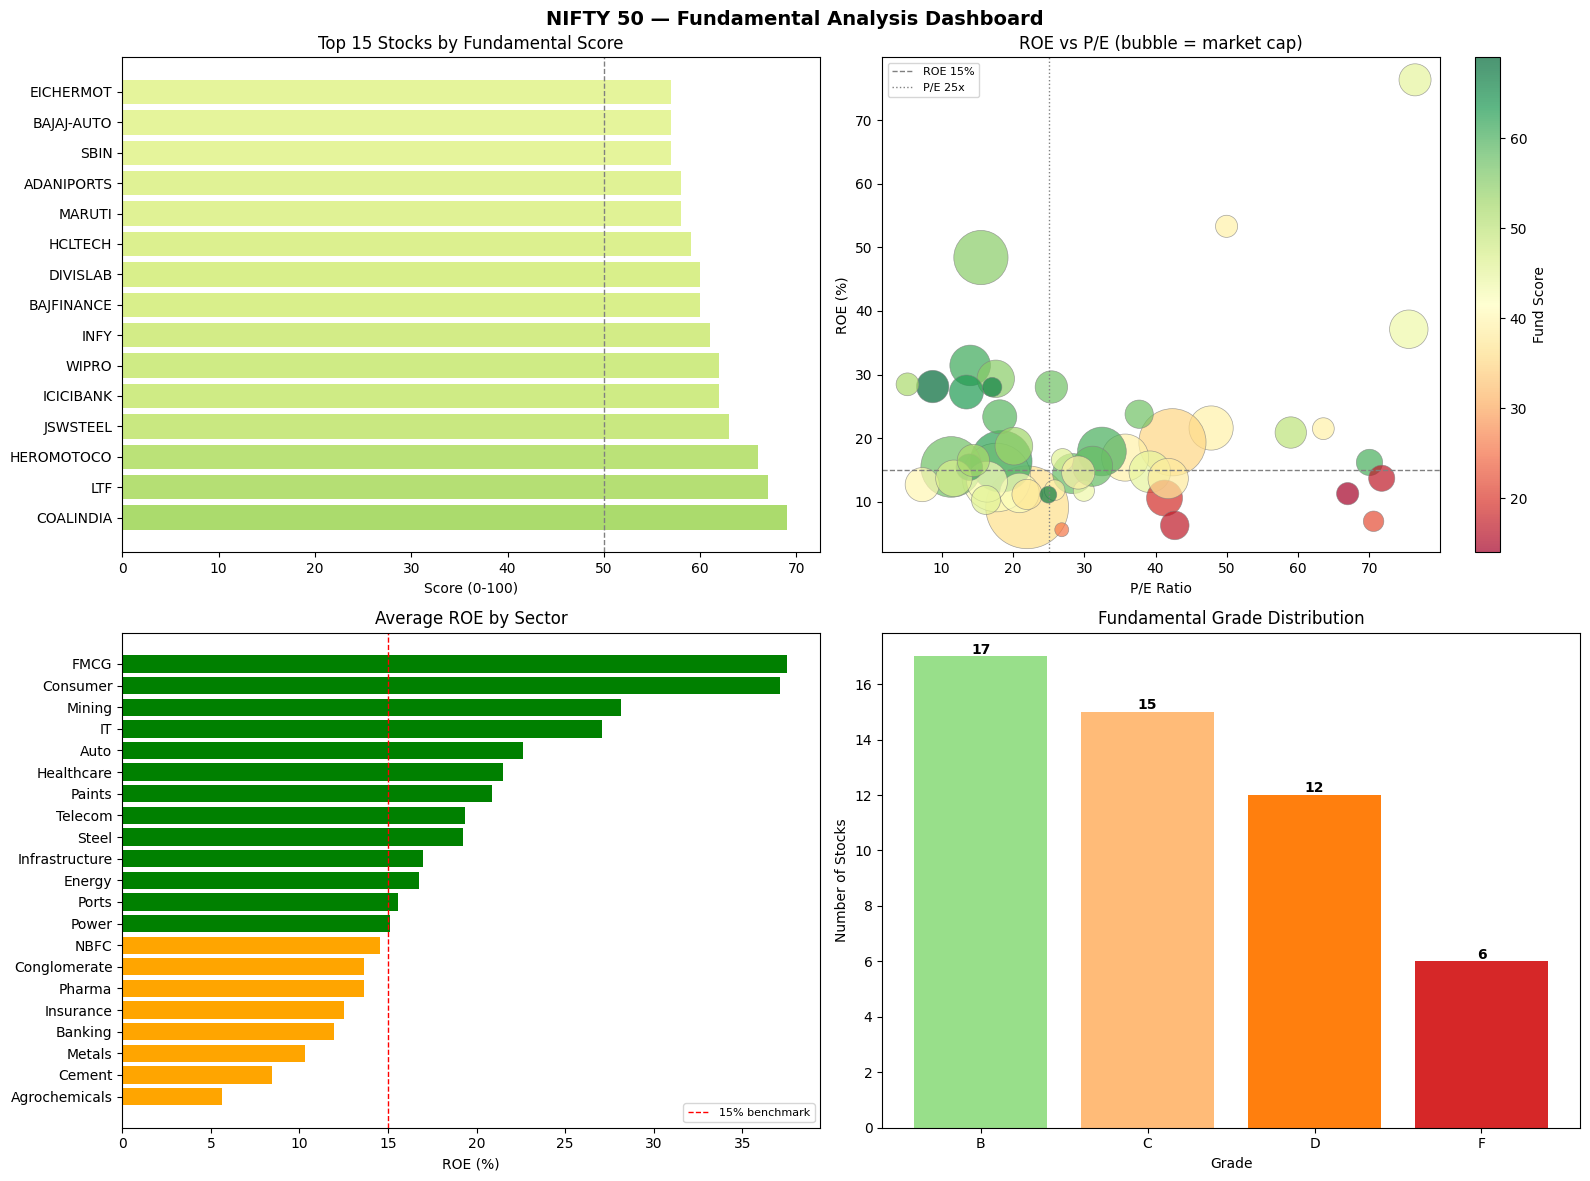

✅ Chart saved to Google Drive!


In [6]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("NIFTY 50 — Fundamental Analysis Dashboard", fontsize=14, fontweight="bold")

# ── Plot 1: Fundamental Score by Stock ──
top15 = fund_df.nlargest(15, "Fund_Score")
colors = cm.RdYlGn(top15["Fund_Score"] / 100)
axes[0,0].barh(top15["Ticker"].str.replace(".NS",""), top15["Fund_Score"], color=colors)
axes[0,0].set_title("Top 15 Stocks by Fundamental Score")
axes[0,0].set_xlabel("Score (0-100)")
axes[0,0].axvline(50, color="gray", ls="--", lw=1)

# ── Plot 2: ROE vs P/E Bubble Chart ──
valid = fund_df.dropna(subset=["PE_Ratio","ROE_Pct","Market_Cap_Cr"])
valid = valid[(valid["PE_Ratio"] > 0) & (valid["PE_Ratio"] < 80)]
scatter = axes[0,1].scatter(
    valid["PE_Ratio"], valid["ROE_Pct"],
    s=valid["Market_Cap_Cr"] / 500,
    c=valid["Fund_Score"], cmap="RdYlGn",
    alpha=0.7, edgecolors="gray", linewidth=0.5
)
axes[0,1].set_title("ROE vs P/E (bubble = market cap)")
axes[0,1].set_xlabel("P/E Ratio")
axes[0,1].set_ylabel("ROE (%)")
axes[0,1].axhline(15, color="gray", ls="--", lw=1, label="ROE 15%")
axes[0,1].axvline(25, color="gray", ls=":",  lw=1, label="P/E 25x")
axes[0,1].legend(fontsize=8)
plt.colorbar(scatter, ax=axes[0,1], label="Fund Score")

# ── Plot 3: Sector Average ROE ──
sector_roe = fund_df.groupby("Sector")["ROE_Pct"].mean().sort_values(ascending=True)
axes[1,0].barh(sector_roe.index, sector_roe.values,
               color=["green" if x > 15 else "orange" for x in sector_roe.values])
axes[1,0].set_title("Average ROE by Sector")
axes[1,0].set_xlabel("ROE (%)")
axes[1,0].axvline(15, color="red", ls="--", lw=1, label="15% benchmark")
axes[1,0].legend(fontsize=8)

# ── Plot 4: Grade Distribution ──
grade_counts = fund_df["Fund_Grade"].value_counts().sort_index()
grade_colors = {"A":"#2ca02c","B":"#98df8a","C":"#ffbb78","D":"#ff7f0e","F":"#d62728"}
axes[1,1].bar(grade_counts.index,
              grade_counts.values,
              color=[grade_colors.get(g,"gray") for g in grade_counts.index])
axes[1,1].set_title("Fundamental Grade Distribution")
axes[1,1].set_xlabel("Grade")
axes[1,1].set_ylabel("Number of Stocks")
for i, (grade, count) in enumerate(grade_counts.items()):
    axes[1,1].text(i, count + 0.1, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{BASE}/data/output/03_fundamental_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to Google Drive!")

In [7]:
def save_fundamental_data(df):

    # Save as Parquet for Python notebooks
    df.to_parquet(f"{BASE}/data/processed/nifty50_fundamentals.parquet", index=False)
    print("✅ Parquet saved")

    # Save as CSV for Power BI
    df.to_csv(f"{BASE}/data/output/nifty50_fundamentals_powerbi.csv", index=False)
    print("✅ CSV for Power BI saved")

    # Save top picks only
    top_picks = df[df["Fund_Grade"].isin(["A","B"])].sort_values(
        "Fund_Score", ascending=False
    )
    top_picks.to_csv(f"{BASE}/data/output/top_fundamental_picks.csv", index=False)
    print(f"✅ Top picks saved — {len(top_picks)} Grade A/B stocks")

    # Summary
    print(f"\n📊 Grade Summary:")
    print(df["Fund_Grade"].value_counts().sort_index().to_string())

save_fundamental_data(fund_df)

✅ Parquet saved
✅ CSV for Power BI saved
✅ Top picks saved — 17 Grade A/B stocks

📊 Grade Summary:
Fund_Grade
B    17
C    15
D    12
F     6


## ✅ Notebook 3 Complete!

**Save to GitHub:**
File → Save a copy in GitHub → `notebooks/03_fundamental_analysis.ipynb`
Commit message: `Add Notebook 3: Fundamental analysis with scoring and grading system`

**Next:** Notebook 4 — Sentiment Analysis (news headlines + NLP scoring)